## О данных

Будем работать с [датасетом физической активности](https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones).

В этом датасете собраны данные 30 человек, выполняющих различные действия со смартфоном на поясе. Данные записывались с помощью датчиков (акселерометра и гироскопа) в этом смартфоне. Были зафиксированы: "3-осевое линейное ускорение" (_tAcc-XYZ_) и "3-осевая угловая скорость" (_tGyro-XYZ_).

1. Все сигналы отсортированы по времени, пропущены через фильтр шума.
2. Все наблюдения были разделены на окна по 128 сигналов в каждом, причем окна пересекаются на 50% (грубо говоря, с 1 по 128 сигнал в 1 окно, с 64 до 192 сигнала - во 2 окно и так далее).
3. Линейное ускорение было разделено на две составляющие (с помощью низкочастотного фильтра): ускорение самого тела, а также гравитационная составляющая. Будем называть их ускорением тела и гравитационным ускорением.
4. К получившимся окнам применяли различные функции для получения следующих показателей:
    - max
    - min
    - mad (median)
    - mean
    - std
    - skewness (коэффициент асимметричности распределения признака в окне)
    - etc. (подробнее, на сколько это возможно, указано на [страничке датасета](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones))
5. Величина (magnitude) сигнала также определялась через евклидову норму всех значений из вектора для одного окна.
6. К окнам было применено преобразование Фурье, чтобы получить частоты. Из частот были извелченыте же показатели, плюс новые:
    - bandsEnergy (энергия частотного интервала)
7. Были посчитаны углы между векторами соответствующих окон.
8. Для ускорений были посчитаны производные - рывки, к которым применялись те же функции.

Итог: в датасете каждый признак - это какая-то операция над вектором из 128 чисел, которые соответствуют замерам определенного человека занятого какой-то активностью на протяжении 2.56 секунд.

Как читать названия признаков? Примеры:
- `tBodyAccMag-mean()` - это вектор ускорений тела (без гравитационной составляющей этого ускорения), из которого взяли евклидову норму, а затем усреднили, чтобы получить скаляр
- `fBodyAcc-bandsEnergy()-1,8.2` - это вектор ускорения тела, к которому применили преобразование Фурье, преобразовав его в вектор частот, а затем посчитали на этом векторе энергию данного частотного интервала в определенном диапазоне частот (в данном случае 1 - 8.2)
- `angle(X,gravityMean)` - это угол между осью Х и вектором усредненных значений гравитационного ускорения из соответствующего окна

Вероятно, сначала покажется сложным, но мы разберемся с некоторыми признаками в отдельности и вы сможете понять их смысл, уже исходя из фактических соотношений.

## Предобработка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
pip install opendatasets

In [ ]:
# введите здесь свой API токен из kaggle
import opendatasets as od

od.download('https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones')

Skipping, found downloaded files in "./human-activity-recognition-with-smartphones" (use force=True to force download)


In [ ]:
train = pd.read_csv('human-activity-recognition-with-smartphones/train.csv')
test = pd.read_csv("human-activity-recognition-with-smartphones/test.csv")

In [ ]:
train.shape

(7352, 563)

In [ ]:
cols_subset = [
    'tBodyAccMag-mean()',  # усредненная величина ускорения тела
    'tBodyGyroJerk-mad()-X',  # медианная величина рывка тела по оси Х
    'tGravityAcc-min()-X',  # минимум гравитационной составляющей ускорения по оси Х
    'tBodyAcc-max()-X',  # максимальная величина ускорения тела по оси Х
    'fBodyAcc-bandsEnergy()-1,8.2',  # энергия ускорения тела в интервале частоты
    'angle(X,gravityMean)',  # угол между осью Х и усредненной гравитационной составляющей ускорения
    'angle(Y,gravityMean)',  # угол между осью Y и усредненной гравитационной составляющей ускорения
    'angle(Z,gravityMean)',  # угол между осью Z и усредненной гравитационной составляющей ускорения,
    'fBodyAcc-skewness()-X',  # асимметричность частоты ускорения тела по оси Х
    'subject',  # номер испытуемого
    'Activity',  # название вида деятельности (целевая переменная)
]

In [ ]:
train = train[cols_subset]
test = test[cols_subset]

### Задание 1 (0.5 балла)

Посмотрите на пропуски и дубли в данных train и test. Есть ли они? Если есть, напишите, с чем это может быть связано? Если нет, то просто напишите, что пропусков и/или дублей нет.

In [ ]:
print(train.isnull().sum())
print(' ', test.isnull().sum(), sep = '\n')
print('\n', 'Количество пропусков в обеих таблицах равно 0')

print('\n', 'Количество дубликатов в таблице train =', train.duplicated().sum())
print('\n', 'Количество дубликатов в таблице test =', test.duplicated().sum())
print('\n', 'Вывод: пропусков и дублей нет')

tBodyAccMag-mean()              0
tBodyGyroJerk-mad()-X           0
tGravityAcc-min()-X             0
tBodyAcc-max()-X                0
fBodyAcc-bandsEnergy()-1,8.2    0
angle(X,gravityMean)            0
angle(Y,gravityMean)            0
angle(Z,gravityMean)            0
fBodyAcc-skewness()-X           0
subject                         0
Activity                        0
dtype: int64
 
tBodyAccMag-mean()              0
tBodyGyroJerk-mad()-X           0
tGravityAcc-min()-X             0
tBodyAcc-max()-X                0
fBodyAcc-bandsEnergy()-1,8.2    0
angle(X,gravityMean)            0
angle(Y,gravityMean)            0
angle(Z,gravityMean)            0
fBodyAcc-skewness()-X           0
subject                         0
Activity                        0
dtype: int64

 Количество пропусков в обеих таблицах равно 0

 Количество дубликатов в таблице train = 0

 Количество дубликатов в таблице test = 0

 Вывод: пропусков и дублей нет


### Задание 2 (0.5 балла)

Выведите основные статистики данных: среднее, медиана, перцентили (0.25, 0.5, 0.75), минимум, максимум, стандартное отклонение. Посмотрите на таблицу и напишите, видите ли вы в ней что-нибудь интересное.


In [ ]:
train.describe()

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,-0.543884,-0.727735,0.678505,-0.468604,-0.847963,-0.489547,0.058593,-0.056515,-0.128562,17.413085
std,0.477653,0.315832,0.508656,0.544547,0.233633,0.511807,0.297480,0.279122,0.403686,8.975143
min,-1.000000,-0.999889,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.931208,1.000000
25%,-0.983282,-0.991595,0.804270,-0.936219,-0.999480,-0.812065,-0.017885,-0.143414,-0.486841,8.000000
50%,-0.883371,-0.950268,0.926693,-0.881637,-0.986582,-0.709417,0.182071,0.003181,-0.163271,19.000000
75%,-0.106892,-0.474625,0.965095,-0.017129,-0.764508,-0.509079,0.248353,0.107659,0.155112,26.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.478157,1.000000,1.000000,30.000000


In [ ]:
test.describe()

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000
mean,-0.559043,-0.735661,0.696878,-0.462063,-0.880361,-0.513923,0.074886,-0.048720,-0.154042,12.986427
std,0.439539,0.282074,0.502873,0.523916,0.160496,0.509205,0.324300,0.241467,0.392203,6.950984
min,-0.998936,-1.000000,-0.756774,-0.952357,-0.999989,-0.984195,-0.913704,-0.949228,-1.000000,2.000000
25%,-0.978433,-0.989078,0.836787,-0.934447,-0.999330,-0.829722,0.022140,-0.098485,-0.497070,9.000000
50%,-0.861830,-0.914698,0.934930,-0.852659,-0.979336,-0.729648,0.181563,-0.010671,-0.202050,12.000000
75%,-0.149596,-0.486423,0.970871,-0.009965,-0.799113,-0.545939,0.260252,0.092373,0.140254,18.000000
max,0.479547,0.117606,0.996148,0.786436,0.048730,0.833180,1.000000,0.973113,0.960367,24.000000


## *Что-нибудь интересное* 👍👍👍
Заметим, что все значения признаков лежат в диапазоне от -1 до 1 (кроме subject, это просто номер испытуемого). Можно предположить, что данные отнормированы к отрезку  [−1;1].

При этом значения признаков неравномерно распределена на этом отрезке, возможно, смещена выборка в какую-либо сторону, или же это особенности данных.

Так, например, 75% значений tBodyAccMag-mean, tBodyGyroJerk-mad-X, tBodyAcc-max-X меньше 0, а fBodyAcc-bandsEnergy-1,8.2 даже меньше -0,7
У tGravityAcc-min-X 25% уже равен 0,8.

При этом, если смотреть на train, в целом максимальные и минимальные значения равны 1 и -1 соответственно, т.е. возможны выбросы.



### Задание 3 (0.5 балла)

Данные сбалансированы? У вас есть 6 категорий активности (целевая переменная). Если одна из категорий представлена большим количеством наблюдений, а остальные - нет, то это обстоятельство, о котором хотелось бы знать заранее. Гиперболизированный пример: представьте, что у вас 1000 наблюдений, разделенных на два класса, и только 5 принадлежат ко второму классу. Как учить модель на такой выборке? Есть сильное подозрение, что многие модели будут склонны вырождаться в константу. Отсюда и необходимость проверять баланс классов.

Выведите количество наблюдений для всех категорий активности в train и test. Посчитайте разницу в процентах между самой крупной категорией и самой маленькой (самая большая категория - это 100%). Если разница (округленная до ближайшего целого числа) не превышает 30%, то давайте для наших целей считать, что данные сбалансированы. Напишите, сбалансированы ли данные в train и test.

In [ ]:
# train
maxAct = max(train['Activity'].value_counts())
minAct = min(train['Activity'].value_counts())
print('Разница в % между самой крупной и самой маленькой категорией = ', round(100 * (maxAct - minAct) / maxAct))
print('Данные в train сбалансированы.')

Разница в % между самой крупной и самой маленькой категорией =  30
Данные в train сбалансированы.


In [ ]:
#test
maxAct = max(test['Activity'].value_counts())
minAct = min(test['Activity'].value_counts())
print('Разница в % между самой крупной и самой маленькой категорией = ', round(100 * (maxAct - minAct) / maxAct))
print('Данные в test сбалансированы.')

Разница в % между самой крупной и самой маленькой категорией =  22
Данные в test сбалансированы.


### Задание 4 (0.5 балла)

Посчитайте корреляции всех признаков (включая таргет) со всеми другими. Какими получились значения? Есть идеи, почему так? Напишите ваши мысли.

In [ ]:
train_ohe = pd.get_dummies(train, columns = ['Activity']) # one hot encoding
test_ohe =  pd.get_dummies(test, columns = ['Activity'])
# закодируя таким образом категории активностей ->
# -> можно посчитать корреляцию значения определенного признака и наличия той или иной категории активности

In [ ]:
# корреляция признаков в train
train_ohe.corr()

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity_LAYING,Activity_SITTING,Activity_STANDING,Activity_WALKING,Activity_WALKING_DOWNSTAIRS,Activity_WALKING_UPSTAIRS
tBodyAccMag-mean(),1.000000,0.899080,0.369962,0.959827,0.697832,-0.370849,0.495561,0.426283,0.379796,-0.073652,-0.396643,-0.396389,-0.414460,0.358825,0.561344,0.405434
tBodyGyroJerk-mad()-X,0.899080,1.000000,0.380118,0.879900,0.507939,-0.382246,0.478567,0.380967,0.266002,-0.110321,-0.386730,-0.379403,-0.370699,0.531695,0.445048,0.257524
tGravityAcc-min()-X,0.369962,0.380118,1.000000,0.380404,0.239088,-0.988663,0.797116,0.667415,-0.261676,-0.042371,-0.973167,0.187055,0.262354,0.234820,0.192409,0.159741
tBodyAcc-max()-X,0.959827,0.879900,0.380404,1.000000,0.613383,-0.384192,0.480229,0.405023,0.335708,-0.055633,-0.394745,-0.387297,-0.399861,0.298526,0.658369,0.347429
"fBodyAcc-bandsEnergy()-1,8.2",0.697832,0.507939,0.239088,0.613383,1.000000,-0.213318,0.363170,0.423927,0.260316,-0.037000,-0.287395,-0.276766,-0.296141,0.189834,0.217399,0.534750
"angle(X,gravityMean)",-0.370849,-0.382246,-0.988663,-0.384192,-0.213318,1.000000,-0.783848,-0.643655,0.265523,0.026137,0.956927,-0.181082,-0.266279,-0.233903,-0.222029,-0.116118
"angle(Y,gravityMean)",0.495561,0.478567,0.797116,0.480229,0.363170,-0.783848,1.000000,0.594885,-0.046213,-0.009829,-0.816776,-0.096667,0.241314,0.243434,0.186124,0.310982
"angle(Z,gravityMean)",0.426283,0.380967,0.667415,0.405023,0.423927,-0.643655,0.594885,1.000000,-0.183815,-0.098712,-0.678385,-0.065389,0.167701,0.198901,0.162849,0.273889
fBodyAcc-skewness()-X,0.379796,0.266002,-0.261676,0.335708,0.260316,0.265523,-0.046213,-0.183815,1.000000,0.019742,0.206542,-0.223813,-0.419856,0.024511,0.176759,0.277785
subject,-0.073652,-0.110321,-0.042371,-0.055633,-0.037000,0.026137,-0.009829,-0.098712,0.019742,1.000000,0.028078,0.029473,0.018212,-0.047385,-0.014201,-0.019371


In [ ]:
# корреляция признаков в test
test_ohe.corr()

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity_LAYING,Activity_SITTING,Activity_STANDING,Activity_WALKING,Activity_WALKING_DOWNSTAIRS,Activity_WALKING_UPSTAIRS
tBodyAccMag-mean(),1.000000,0.934773,0.407084,0.965114,0.767875,-0.400871,0.439051,0.425011,0.365670,-0.057359,-0.432375,-0.401367,-0.414812,0.382256,0.533885,0.399410
tBodyGyroJerk-mad()-X,0.934773,1.000000,0.393773,0.898628,0.625414,-0.387274,0.423288,0.368411,0.278765,-0.079811,-0.409460,-0.395664,-0.379256,0.522026,0.464393,0.255742
tGravityAcc-min()-X,0.407084,0.393773,1.000000,0.386764,0.301643,-0.989043,0.697006,0.633881,-0.237864,0.004927,-0.983505,0.196159,0.244371,0.227835,0.193024,0.163337
tBodyAcc-max()-X,0.965114,0.898628,0.386764,1.000000,0.707129,-0.384454,0.410477,0.398008,0.338543,-0.071786,-0.407889,-0.396788,-0.408003,0.281951,0.638335,0.364582
"fBodyAcc-bandsEnergy()-1,8.2",0.767875,0.625414,0.301643,0.707129,1.000000,-0.279783,0.327473,0.446245,0.293881,-0.090817,-0.342430,-0.295023,-0.323854,0.213190,0.270809,0.524637
"angle(X,gravityMean)",-0.400871,-0.387274,-0.989043,-0.384454,-0.279783,1.000000,-0.668108,-0.615114,0.235208,0.003138,0.966505,-0.203741,-0.240721,-0.229489,-0.218656,-0.115408
"angle(Y,gravityMean)",0.439051,0.423288,0.697006,0.410477,0.327473,-0.668108,1.000000,0.425454,-0.087006,-0.047553,-0.725073,-0.058690,0.200925,0.193011,0.160255,0.262663
"angle(Z,gravityMean)",0.425011,0.368411,0.633881,0.398008,0.446245,-0.615114,0.425454,1.000000,-0.208121,0.055885,-0.649058,-0.043474,0.109366,0.166195,0.164282,0.286753
fBodyAcc-skewness()-X,0.365670,0.278765,-0.237864,0.338543,0.293881,0.235208,-0.087006,-0.208121,1.000000,0.015103,0.224384,-0.274466,-0.411989,0.034471,0.237610,0.213281
subject,-0.057359,-0.079811,0.004927,-0.071786,-0.090817,0.003138,-0.047553,0.055885,0.015103,1.000000,0.019262,0.017383,0.021736,-0.042317,-0.006886,-0.011007


## *Тут какие-то мои мысли* ⬇

Удобнее смотреть на heatmap в задании 7, но если просят написать наблюдения здесь, то напишу здесь.

На главной диагонали стоят единички, тк это корреляции признака с самим собой, логично, что идеальная корреляция.

Также высокая (близкая по модулю к 1) корреляция наблюдается у признаков, в основе которых лежит одно и то же, например, tBodyAccMag-mean() и tBodyAcc-max()-X (в train $corr = 0.96$), а также у величин, которые каким-то образом связаны со стороны физики (tBodyAccMag-mean() и tBodyAccMag-mean()) (возможно, в их основе тоже лежат одинаковые величины, кто знает......)

Что касается корреляцию с таргетом, категория Laying сильно коррелирует с величинами, в которых присутствует гравитационная составляющая.

Поздравляем! Вы предобработали данные для максимально комфортного их последующего анализа. Теперь вы готовы приступить к Exploratory Data Analysis!

## Exploratory Data Analysis

### Задание 5 (0.5 балла)

Вы проверили основную информацию о данных и составили свое первое впечатление о них. Теперь визуализации.

Начнем рисовать графики с небольшой разминки. Выберите две любые математические функции (отличные от линейной) и нарисуйте их на одном графике. Подпишите каждый из графиков, чтобы было понятно, какие функции вы выбрали. Ниже будет пример.

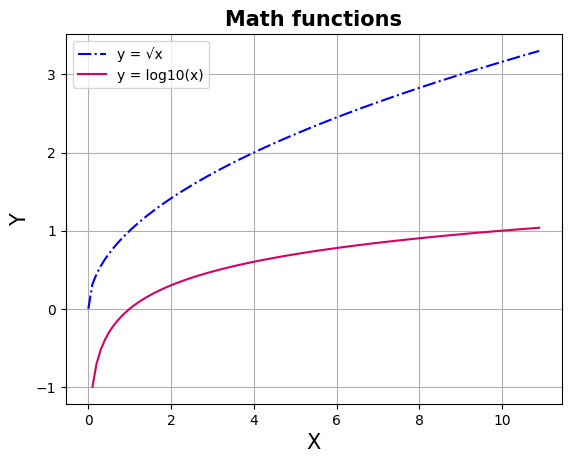

In [ ]:
x = np.arange(0, 11, 0.1)
y = x ** 0.5

x2 = np.arange(0, 11, 0.1)
y2 = np.log10(x2)

plt.plot(x, y, color = 'blue', linestyle = '-.', label = 'y = \u221ax')
plt.plot(x2, y2, color = '#D60062', label = 'y = log10(x)')
plt.xlabel('X', fontsize = 15)
plt.ylabel('Y', fontsize = 15)
plt.title('Math functions', fontsize = 15, fontweight = 'heavy')
plt.grid(True)
plt.legend()
plt.show()

### Задание 6 (0.5 балла)

Ранее мы уже проверили сбалансированность данных по разным категориям активностей в train и test сетах. Теперь визуализируйте количество сэмплов в каждой из категорий отдельно для train и test сетов, как в примере ниже. Проследите, чтобы порядок категорий слева и справа был одинаков. Иначе не очень удобно их сравнивать (когда они в разных местах двух графиков). Также заметьте, что в примере ось Х в одинаковом масштабе, что тоже удобно для сравнения.

Вам может пригодиться:
- plt.barh или ax.barh

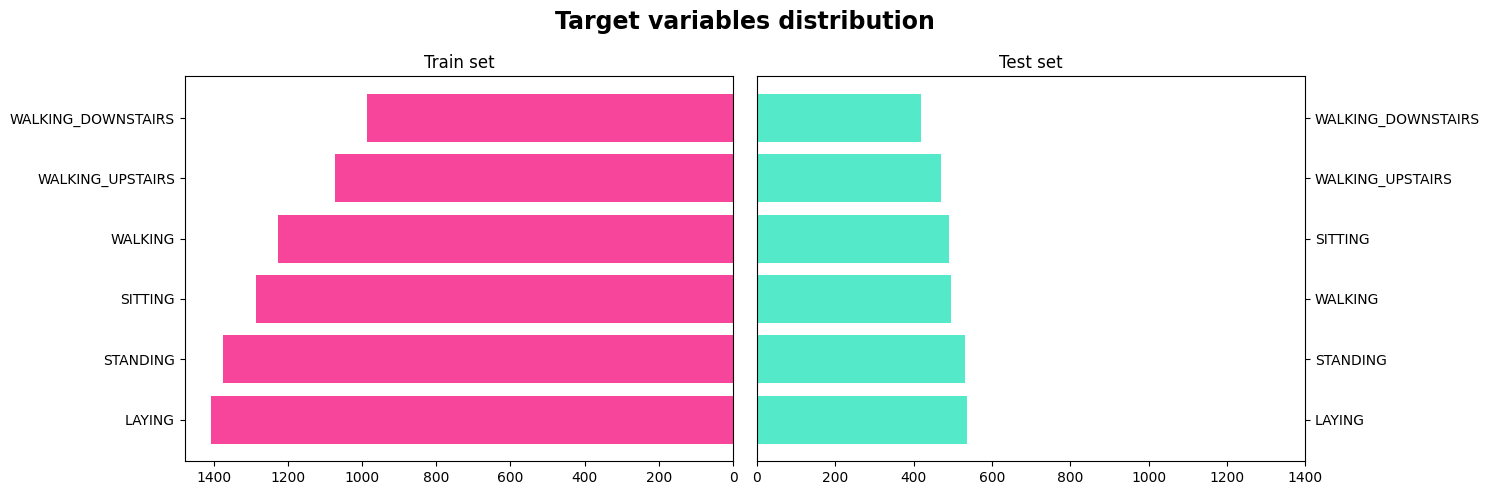

In [ ]:
act_train = train['Activity'].value_counts().index
value_train = train['Activity'].value_counts().values

act_test = test['Activity'].value_counts().index
value_test = test['Activity'].value_counts().values

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].barh(act_train, value_train, color = '#f8459c')
axs[0].set_title('Train set')
axs[0].invert_xaxis()

axs[1].barh(act_test, value_test, color = '#54e9c8')
axs[1].set_title('Test set')
axs[1].yaxis.tick_right()

fig.suptitle('Target variables distribution', fontsize = 17, fontweight = 'heavy')
plt.setp(axs, xticks = np.arange(0, 1401, 200))
fig.tight_layout()

plt.show()

Правда на таких графиках проще проверять баланс классов таргета?)

### Задание 7 (0.5 балла)

Ранее вы выводили таблицу корреляций. Однако просто таблица корреляций не очень удобна для анализа. Что, если признаков было бы больше? Визуализируйте heatmap корреляций. Подпишите значения корреляций, округленные до 2 знаков после запятой, на графике и оставьте только те значения, которые по модулю не меньше 0.5. Будем считать такие корреляции существенными. Если будете брать код из семинарского ноутбука, то поменяйте в нем что-нибудь, например, цветовую гамму, иначе проверяющий будет карать :)

Какой признак стоит исключить из рассмотрения корреляций? Напишите его название, а также причину, почему нет смысла его рассматривать.

Вам может пригодиться:
- sns.heatmap
- методы get_text и set_text у атрибута texts графика

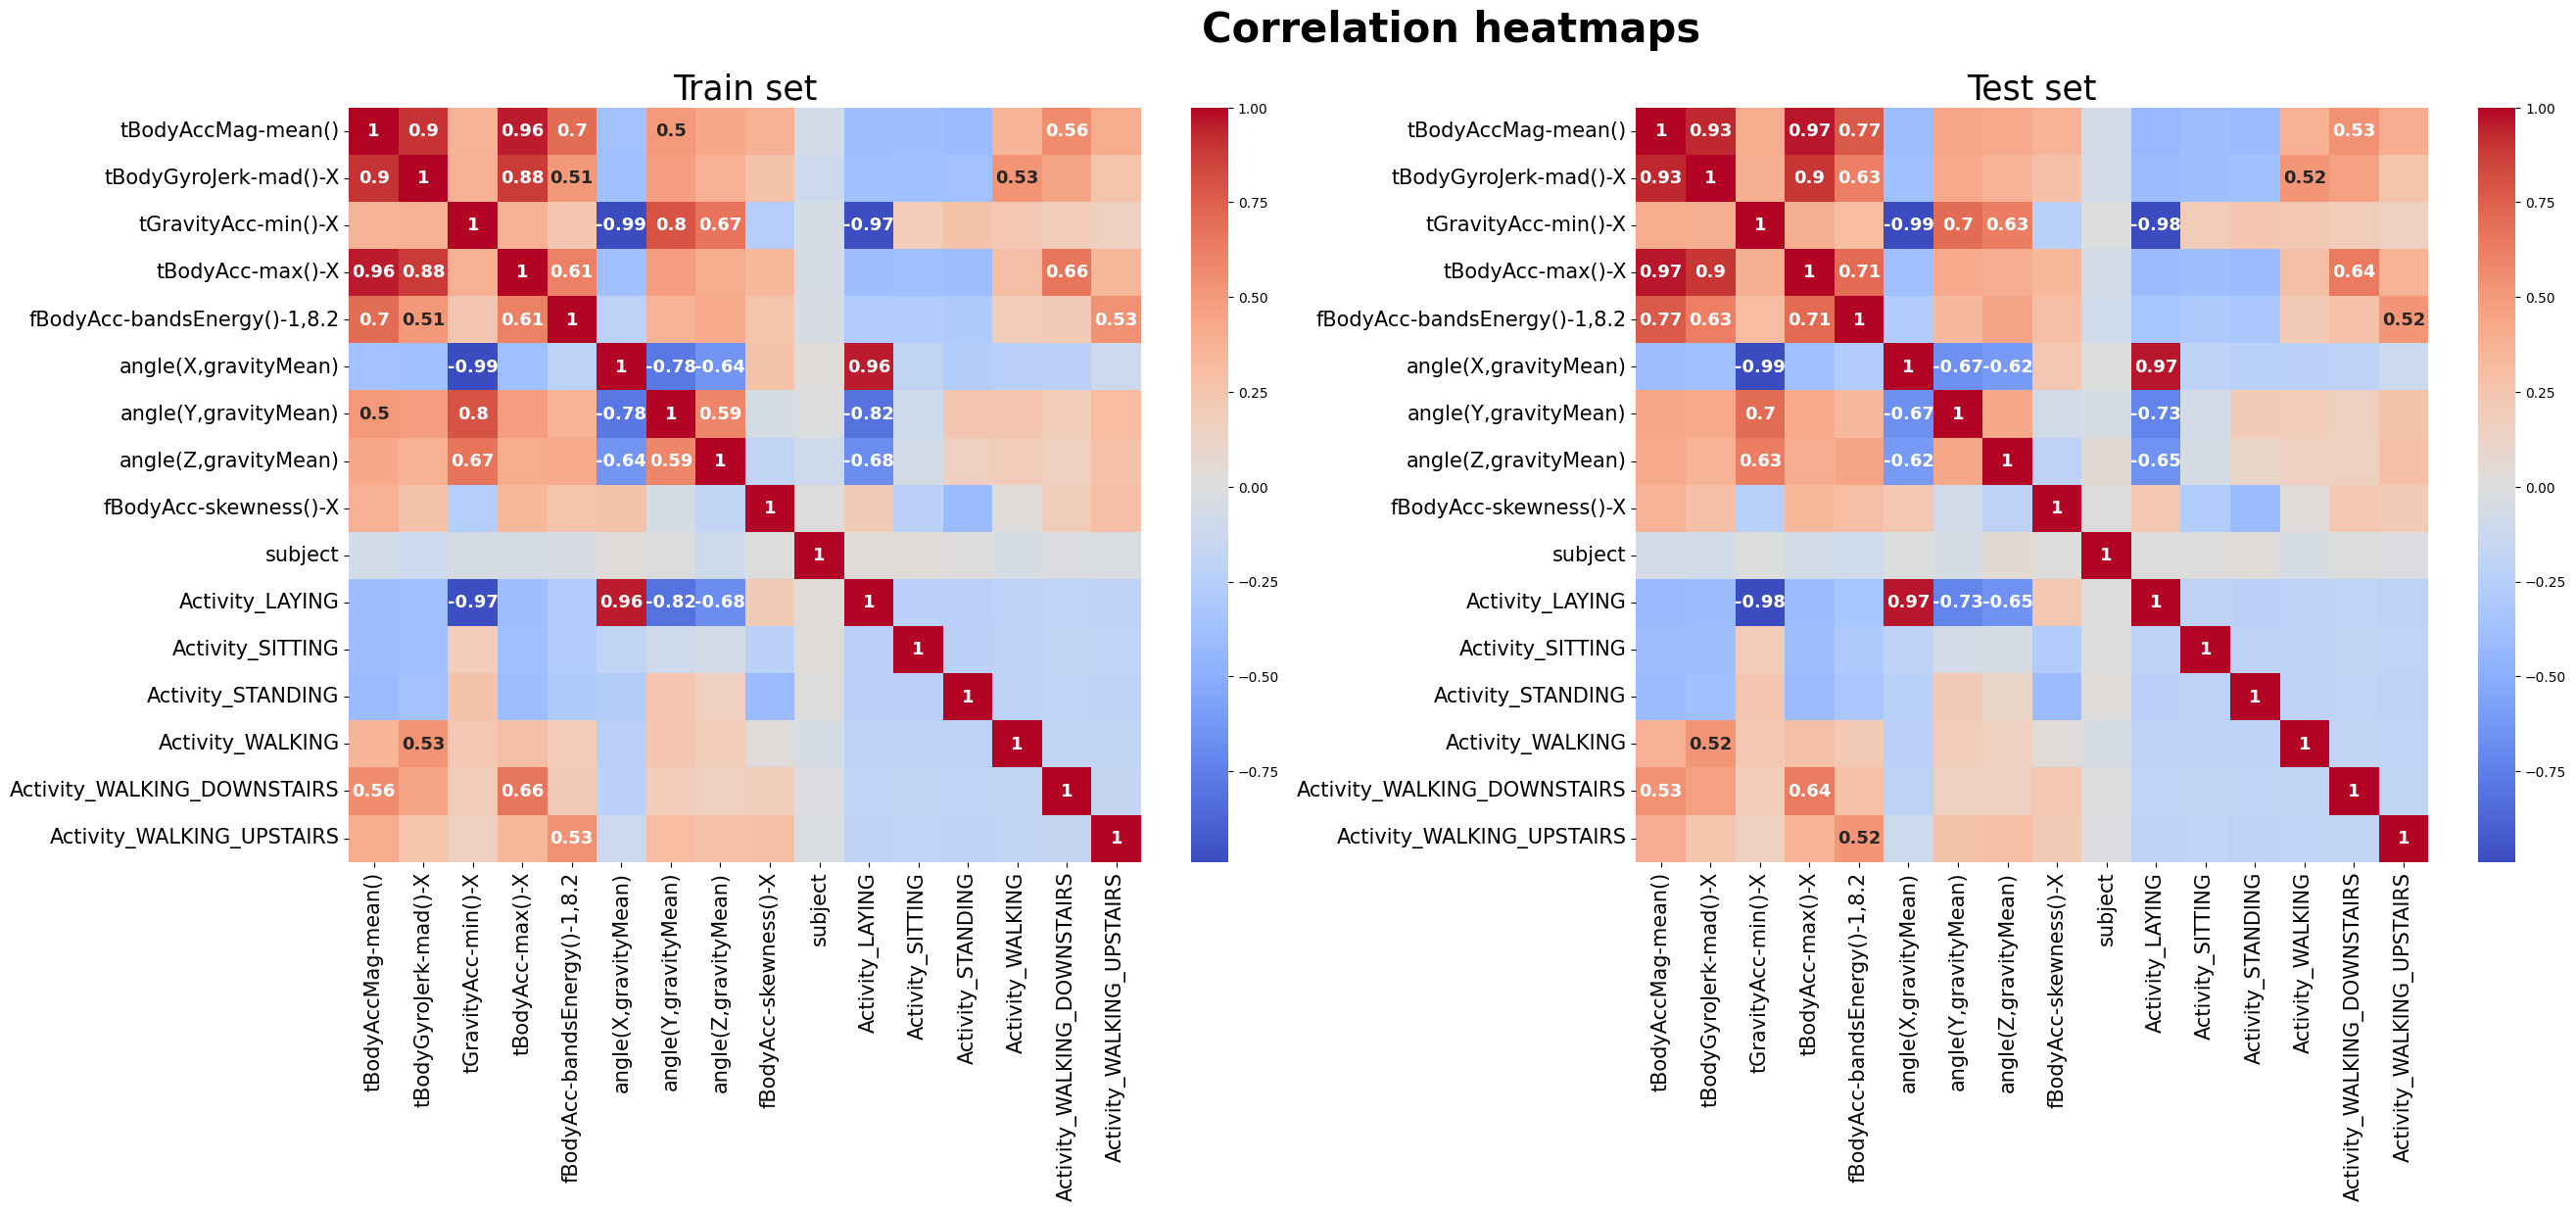

In [ ]:
fig, axs = plt.subplots(1, 2, figsize = (30, 10))
sns.heatmap(train_ohe.corr(), cmap = 'coolwarm', ax = axs[0], annot = True, annot_kws={'size': 13, 'weight': 'heavy'})
sns.heatmap(test_ohe.corr(), cmap = 'coolwarm', ax = axs[1], annot = True, annot_kws={'size': 13, 'weight': 'heavy'})

for i in range(2):
  for j in axs[i].texts:
      if float(j.get_text()) >= 0.5 or float(j.get_text()) <= -0.5:
          j.set_text(j.get_text())
      else:
          j.set_text("")

plt.subplots_adjust(wspace = 0.3)
fig.suptitle('Correlation heatmaps', fontsize = 30, fontweight = 'heavy')

axs[0].set_title('Train set', fontsize = 25)
axs[0].tick_params(axis = 'both', labelsize = 15)
axs[1].set_title('Test set', fontsize = 25)
axs[1].tick_params(axis = 'both', labelsize = 15)

plt.show()

### Из рассмотрения стоит исключить признак subject, так как это просто номер испытуемого, который не влияет ни на что.

### Задание 8 (0.5 балла)

Для начала будем стрелять из пушки по воробьям. Выведите pairplot по всем данным train сета. Напишите, заметили ли вы в нем что-нибудь интересное, чего не было в таблицах и графиках ранее, а также сообщите, было ли вам удобно анализировать 100 графиков.

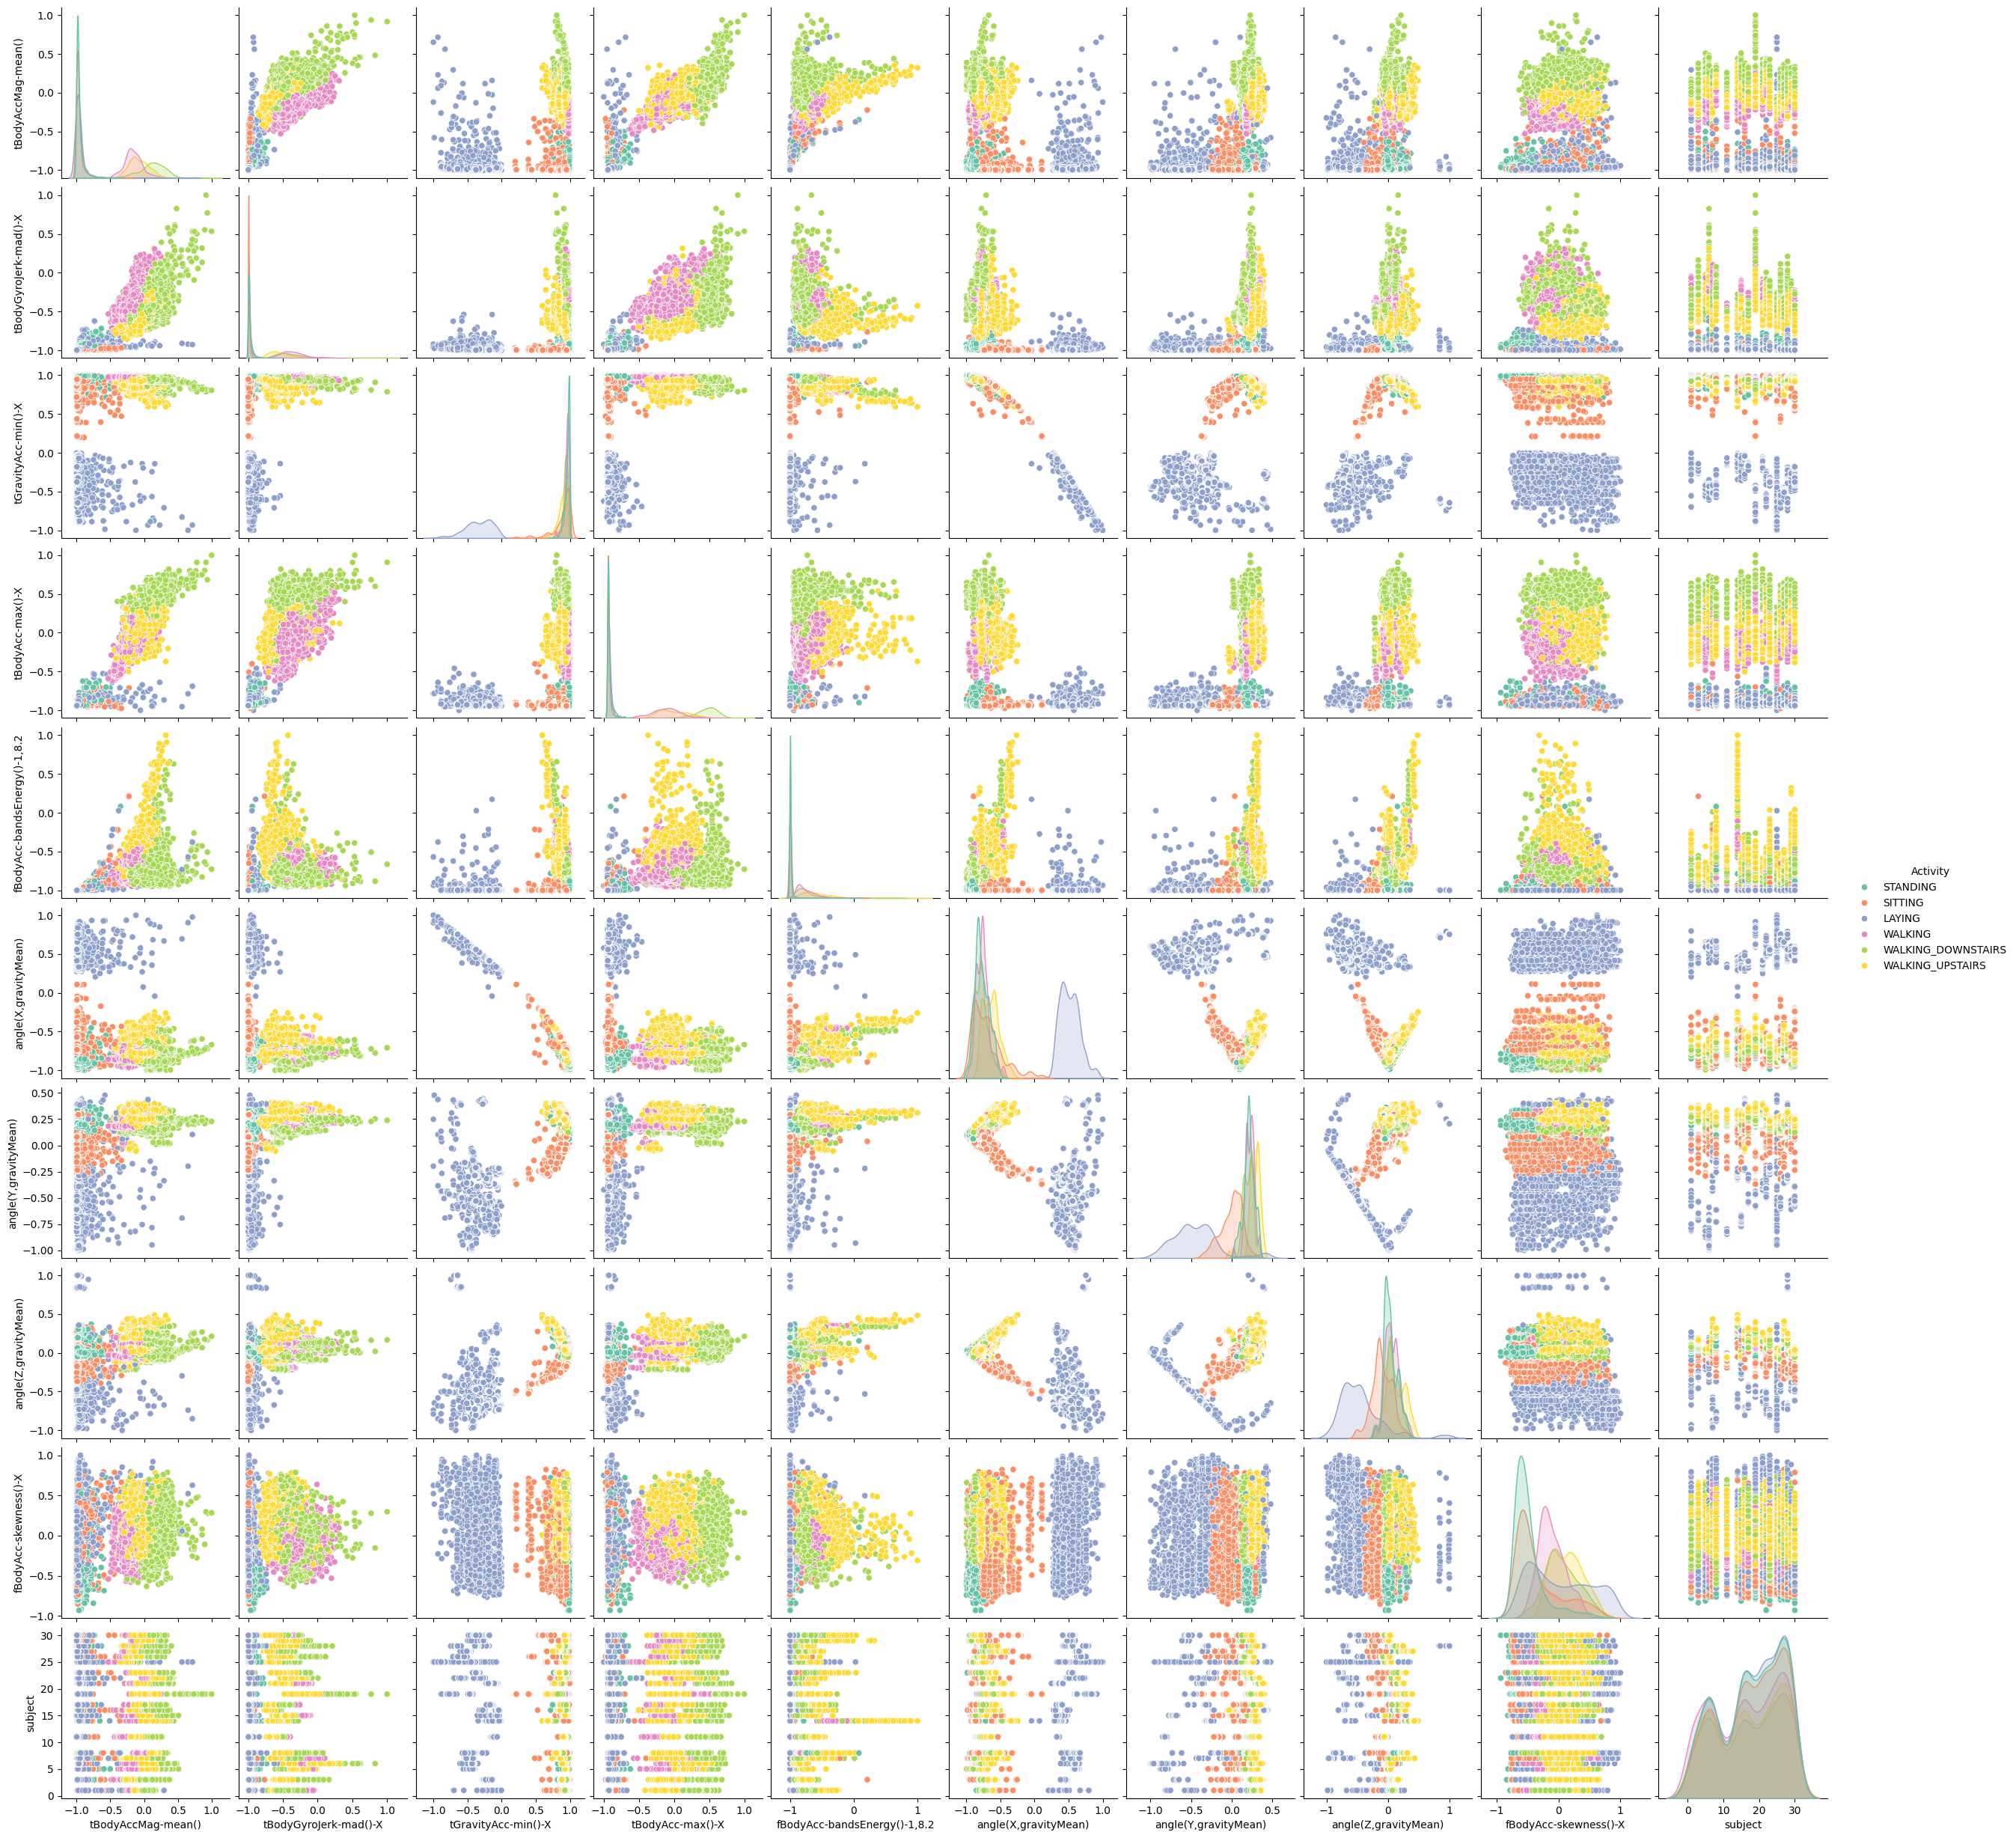

In [ ]:
sns.pairplot(train, hue = 'Activity', palette = 'Set2')
plt.show()

### Очень тяжко анализировать это сборище микрографичков, но как будто на некоторых из них есть разделение на две кучки (standing, sitting, laying - 1, walking, walking downstairs, walking upstairs - 2). Также много где выделяется laying.

### Задание 9 (1 балл)

Окей. Смотреть на все сразу не очень удобно. Кажется, нужно смотреть на признаки в отдельности и искать в них инсайты.

Попробуем проверить гипотезу. Отобразите плотность распределения (kde) `tBodyAccMag-mean()` для каждой из активностей, как в примере ниже. Видите закономерность? Можно ли поделить все активности на две группы? Если да, то проведите вертикальную линию, которая визуально неплохо разделяет эти группы.

Давайте первую группу называть статическими активностями, а вторую - динамическими.

Посчитайте, какую долю правильных ответов дает ваша вертикальная линия для разделения именно этих двух групп. С чем может быть связан полученный вами результат? Предположите логическое обоснование (почему именно данный признак так хорошо/плохо разделяет группы активностей).

Вам может пригодиться:
- sns.kdeplot

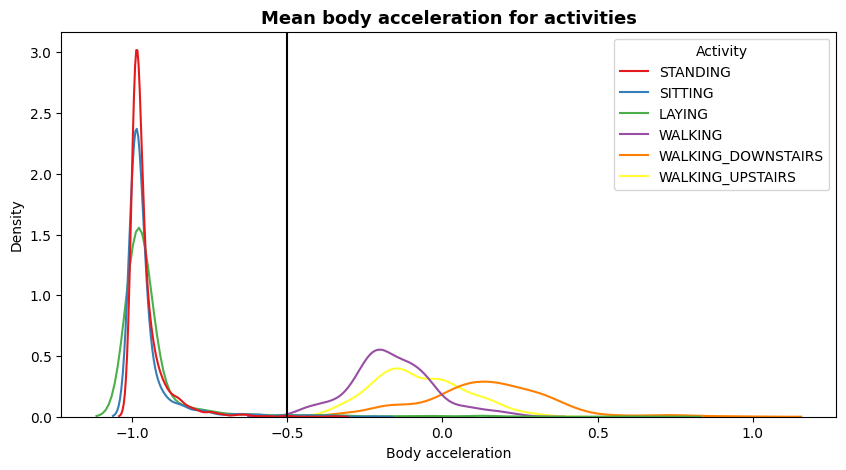

In [ ]:
fig, ax = plt.subplots(figsize = (10, 5))
sns.kdeplot(data = train, x = 'tBodyAccMag-mean()', hue = 'Activity', palette = 'Set1')
ax.axvline(x = -0.5, color = 'black')
ax.set_title('Mean body acceleration for activities', fontsize = 13, fontweight = 'heavy')
ax.set_xlabel('Body acceleration')
plt.show()

In [ ]:
limit = -0.5
stand = sum(train[train['tBodyAccMag-mean()'] < limit]['Activity'] == 'STANDING')
lay = sum(train[train['tBodyAccMag-mean()'] < limit]['Activity'] == 'LAYING')
sit = sum(train[train['tBodyAccMag-mean()'] < limit]['Activity'] == 'SITTING')
walk = sum(train[train['tBodyAccMag-mean()'] >= limit]['Activity'] == 'WALKING')
walk_down = sum(train[train['tBodyAccMag-mean()'] >= limit]['Activity'] == 'WALKING_DOWNSTAIRS')
walk_up = sum(train[train['tBodyAccMag-mean()'] >= limit]['Activity'] == 'WALKING_UPSTAIRS')

correct = 100 * (stand + lay + sit + walk + walk_down + walk_up) / train.shape[0]
print('Доля правильных ответов =', correct, '%')

Доля правильных ответов = 99.22470076169749 %


## *Обоснование*

Доля правильных ответов получилась высокая, значит, признак усредненная величина ускорения тела хорошо справляется со своей работой и делит виды активностей на динамичные и статические.

Ускорение тела тем выше, чем динамичнее активность. Если человек лежит, сидит или стоит, то он не двигается, значит ускорение равно нулю. Если же человек ходит (по лестнице или просто по дорожке), то ускорение тела не нулевое.

Если предположить, что нормировка была произведена таким образом, что 0 превратился в -1, а остальные значения как-то распределились на отрезке [-1; 1], то все сходится.

### Задание 10 (0.5 балла)

Поздравляем, вы проверили первую гипотезу в процессе EDA. Однако нам бы хотелось уметь не группы разделять, а каждый отдельный вид активности. Попробуйте нарисовать "ящики с усами" для `angle(X,gravityMean)` с разделением по разным видам активности на данных train. Можно ли сделать какой-то вывод по полученной визуализации? Проанализируйте и проинтерпретируйте полученные картинки (если заметили какую-то особенность, может какая-то категория значительно выделяется, то предположите, почему так могло произойти).

Вам может пригодиться:
- sns.boxplot

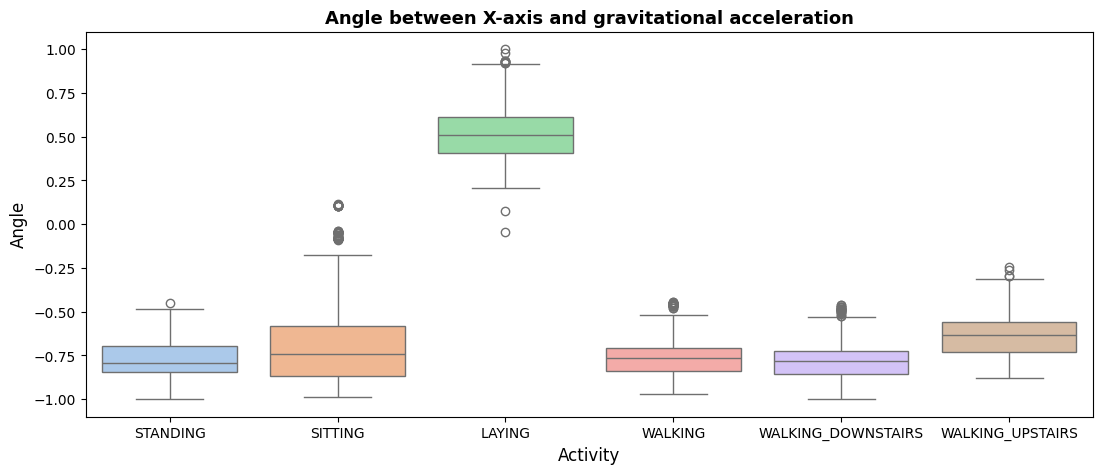

In [ ]:
fig, ax = plt.subplots(figsize = (13, 5))
sns.boxplot(train, x = 'Activity', y = 'angle(X,gravityMean)', hue = 'Activity', palette = 'pastel')
ax.set_title('Angle between X-axis and gravitational acceleration', fontsize = 13, fontweight = 'heavy')
ax.set_xlabel('Activity', fontsize = 12)
ax.set_ylabel('Angle', fontsize = 12)
plt.show()

### Категория активности laying значительно выделяется по сравнению с другими, а именно угол между осью Х и усредненной гравитационной составляющей ускорения выше у лежачих по сравнению с другими. Это может быть по причине того, что положение телефонов, делающих замеры, у людей в категории laying отличается от остальных (из-за положения людей)

### Задание 11 (0.5 балла)

Посмотрим теперь на `tBodyAcc-max()-X`. Визуализируйте скрипичные диаграммы для этого признака с разделением по активностям на всем train. Кажется логичным, что максимальное ускорение в моменте для разных активностей будет различаться. Однако есть ли активность, которая будет выделяться? Если да, то предложите объяснение, почему эта активность выделяется.

Вам может пригодиться:
- sns.violinplot

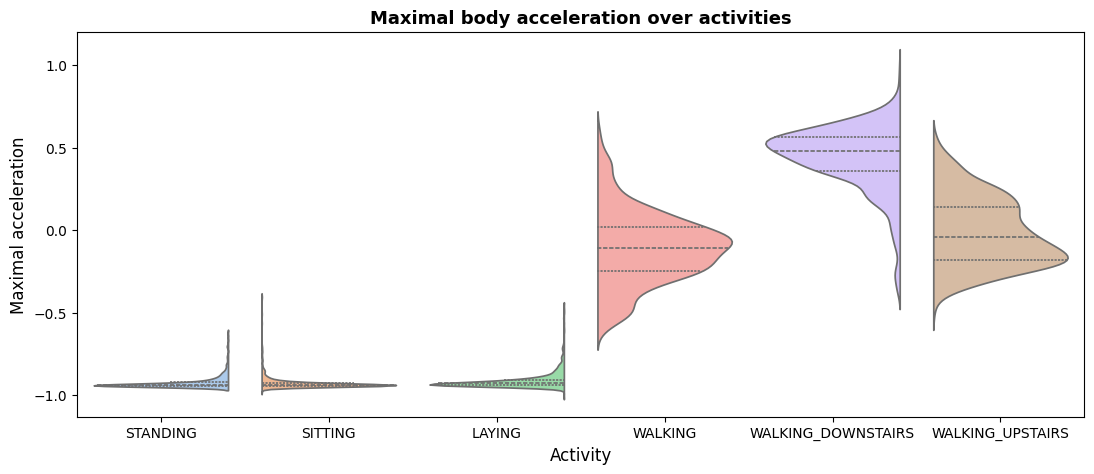

In [ ]:
fig, ax = plt.subplots(figsize = (13, 5))
sns.violinplot(train, x = 'Activity', y = 'tBodyAcc-max()-X', hue = 'Activity', split = True, inner = 'quart', palette = 'pastel')
ax.set_title('Maximal body acceleration over activities', fontsize = 13, fontweight = 'heavy')
ax.set_xlabel('Activity', fontsize = 12)
ax.set_ylabel('Maximal acceleration', fontsize = 12)
plt.show()

### Выделяется категория walking downstairs, максимальная величина ускорения тела по оси Х выше при данной активности выше, чем при остальных. Может быть связано с тем, что спускаться вниз легче, чем идти по прямой и тем более вверх, поэтому выше и скорость, и ускорение.

### Задание 12 (1 балл)

Вы уже можете с довольно хорошим качеством выделить две категории активности из шести. Продолжим.

Ранее уже упоминалось разделение на две группы активностей: статические и динамические. Пришла пора разделить датасет train на две части. Сделайте это! Теперь на одной картинке покажите распределения `fBodyAcc-bandsEnergy()-1,8.2` для динамичных активностей (boxenplot - немного измененый "ящик с усами") и `angle(Y,gravityMean)` для статических - тут хватит и простой гистограммы (прямо, как в примере ниже). Можно ли выделить еще какие-то активности? Если да, напишите, какие активности на 1 и 2 графиках выделяются.

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec (заметили, что один график больше другого? попробуйте сами так сделать - вам понравится...)
- sns.boxenplot
- sns.histplot

In [ ]:
from matplotlib import gridspec

In [ ]:
st = (train['Activity'] == 'LAYING') | (train['Activity'] == 'SITTING') | (train['Activity'] == 'STANDING')
static = train[st]

din = (train['Activity'] == 'WALKING') | (train['Activity'] == 'WALKING_DOWNSTAIRS') | (train['Activity'] == 'WALKING_UPSTAIRS')
dinamic = train[din]

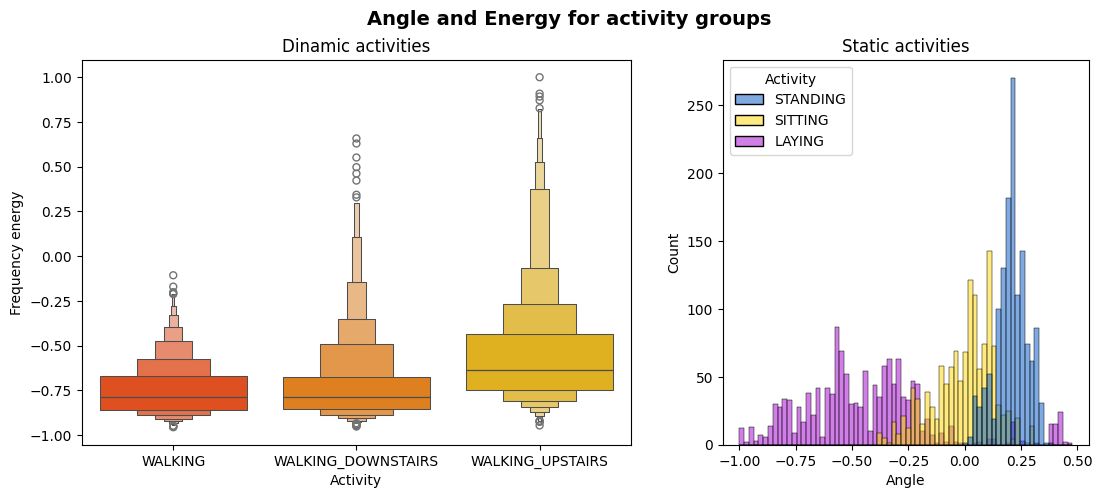

In [ ]:
fig = plt.figure(figsize = (13, 5))
gr = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])

ax1 = fig.add_subplot(gr[0, 0])
ax1 = sns.boxenplot(dinamic, x = 'Activity', y = 'fBodyAcc-bandsEnergy()-1,8.2', palette = 'autumn')
ax1.set_title('Dinamic activities')
ax1.set_ylabel('Frequency energy')

ax2 = fig.add_subplot(gr[0, 1])
ax2 = sns.histplot(static, x = 'angle(Y,gravityMean)', hue = 'Activity', bins = 70, palette  = 'prism')
ax2.set_title('Static activities')
ax2.set_xlabel('Angle')

fig.suptitle('Angle and Energy for activity groups', fontsize = 14, fontweight = 'heavy')

plt.show()

## *1 график*
Не очень поняла, что такое энергия ускорения тела в интервале частоты, но допустим, это энергия, которую нужно приложить телу для ускорения????
У walking и walking downstairs в основном одинаковая энергия, но у downstairs больше разброс данного значения. Выделяется walking upstairs, у этой активности значение в основном выше, возможно, потому что при ходьбе вверх по лестнице тело вырабатывает больше всего энергии.
## *2 график*
Угол между осью Y и усредненной гравитационной составляющей ускорения - что бы это ни значило - у standing распределено более сжато в отличие от других категорий. То есть все значения приходятся на отрезок [0; 0.3]


### Задание 13 (0.5 балла)

Не всегда жизнь будет такой легкой, а данные будут полностью или почти линейно разделимы в одному признаку (иначе чем бы занимались дата саентисты...). Часто данные вообще ни по одному признаку нельзя адекватно разделить (да и по комбинациям признаков тоже). Давайте попробуем взять не один признак, а целых два!

Рассмотрим только статические активности. Будет снова два графика сразу. На первом графике будет боксплот распределения `fBodyAcc-skewness()-X` по активностям. А на втором попробуем взять не все наблюдения данной группы активностей, а только их часть. Разделимы ли категории по `fBodyAcc-skewness()-X`? А если взять только те строки, где `fBodyAcc-skewness()-X < -0.376`, и теперь вывести боксплот распределения `angle(Y,gravityMean)` по разным активностям? Попробуйте и напишите, выделилась ли какая-то категория?

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec
- sns.boxplot

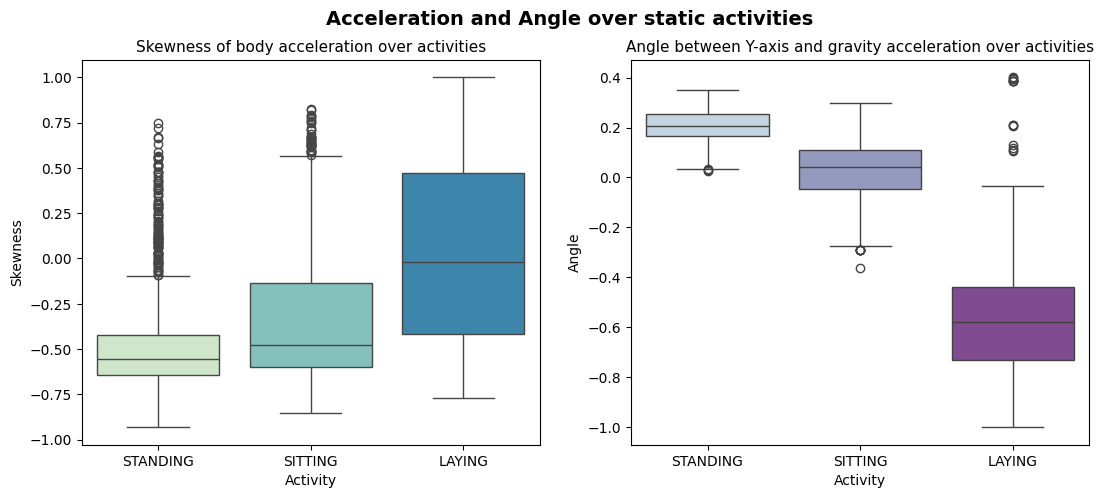

In [ ]:
aa = static[static['fBodyAcc-skewness()-X'] < -0.376]

fig = plt.figure(figsize = (13, 5))
gr = gridspec.GridSpec(1, 2)

axs1 = fig.add_subplot(gr[0, 0])
axs1 = sns.boxplot(static, x = 'Activity', y = 'fBodyAcc-skewness()-X', hue = 'Activity', palette = 'GnBu')
axs1.set_title('Skewness of body acceleration over activities', fontsize = 11)
axs1.set_ylabel('Skewness')

axs2 = fig.add_subplot(gr[0, 1])
axs2 = sns.boxplot(aa, x = 'Activity', y = 'angle(Y,gravityMean)', hue = 'Activity', palette = 'BuPu' )
axs2.set_title('Angle between Y-axis and gravity acceleration over activities', fontsize = 11)
axs2.set_ylabel('Angle')

fig.suptitle('Acceleration and Angle over static activities', fontsize = 14, fontweight = 'heavy')

plt.show()

### Здесь на первом графике если skewness ниже ~ -0.1 трудно сказать, что за активность будет. Однако на втором графике все три активности легко различимы. Логичнее всего по этим признакам выделять standing, так как мы условием на skewness обрубили основную часть standing, и на втором графике можем его выделить. Но standing мы уже выделили в предыдущем пункте, поэтому предположу, что здесь выделяется в том числе и sitting. Для лучшего его выделения нужно взять skewness примерно < 0 (гипотеза)

Поздравляем, теперь вы на шажок ближе к тому, чтобы стать решающим деревом!

### Задание 14 (1 балл)

Вот и осталась лишь одна активность, которую мы никак не выделили. Попробуем и ее какими-то порогами отделить от всех остальных. Да, можно было бы сказать, что, раз уж мы выделили 5 из 6 категорий, то все остальное - это и есть последняя категория, но мы не идем легкими путями. Выделить оставшуюсь категорию с хорошим качеством не так уж и просто. Из доступных признаков, сначала посмотрите на распределение `tBodyAcc-max()-X` на динамических активностях (скрипичная диаграмма отлично подойдет).

А теперь спускаем вам порог `tBodyAcc-max()-X < 0.157`. Для таких строк постройте диаграмму рассеяния для признака `tGravityAcc-min()-X`. Да, получается неидеально, но это честная работа. Можно выбрать порог так, чтобы чисто из таблицы с динамическими активностями из строк, где `tBodyAcc-max()-X < 0.157`, выбрать по некоторому порогу для `tGravityAcc-min()-X` строки так, чтобы доля правильных ответов на оставшейся категории была не меньше 83%!

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec
- sns.violinplot
- sns.swarmplot (иногда лучше подходит, чем просто sns.scatterplot)

Обратите внимание, что подписи к осям можно убирать методами plt. Например, если у вас общее название для оси Y для обоих графиков, то можно не подписывать ось Y у второго графика.

Text(0.5, 0.98, 'Body and gravity accereation over dinamic activities')

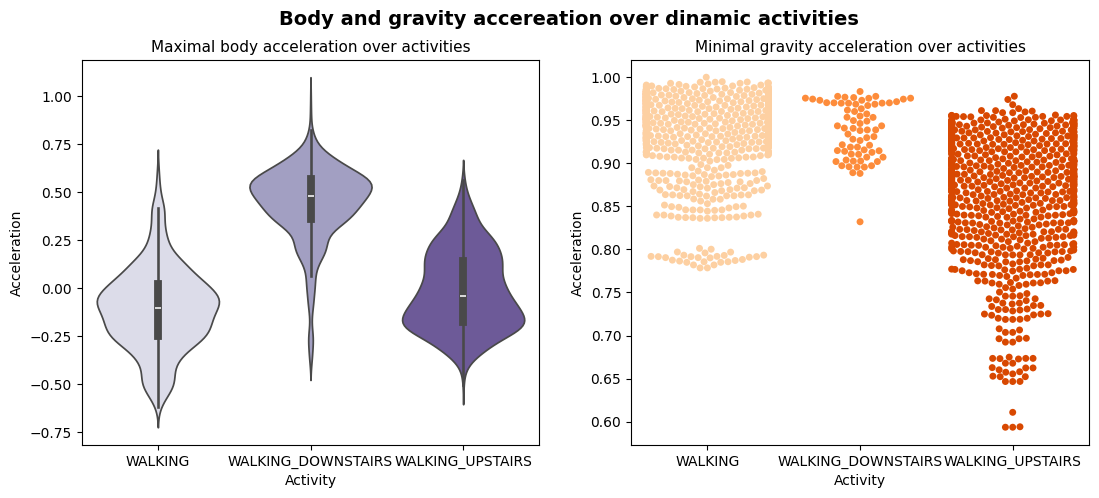

In [ ]:
bb = dinamic[dinamic['tBodyAcc-max()-X'] < 0.157]

fig = plt.figure(figsize = (13, 5))
gr = gridspec.GridSpec(1, 2)

axs1 = fig.add_subplot(gr[0, 0])
axs1 = sns.violinplot(dinamic, x = 'Activity', y = 'tBodyAcc-max()-X', hue = 'Activity', palette = 'Purples')
axs1.set_title('Maximal body acceleration over activities', fontsize = 11)
axs1.set_ylabel('Acceleration')

axs2 = fig.add_subplot(gr[0, 1])
axs2 = sns.swarmplot(bb, x = 'Activity', y = 'tGravityAcc-min()-X', hue = 'Activity', palette = 'Oranges')
axs2.set_title('Minimal gravity acceleration over activities', fontsize = 11)
axs2.set_ylabel('Acceleration')

fig.suptitle('Body and gravity accereation over dinamic activities', fontsize = 14, fontweight = 'heavy')

In [ ]:
# порог для walking
walk = bb[bb['tGravityAcc-min()-X'] > 0.9331]
correct_walk = np.sum(walk['Activity'] == 'WALKING') / walk.shape[0]
print('Доля правильных ответов = ', 100 * correct_walk, '%')
print('Порог, чтобы правильных ответов было не менее 83% = 0.9331')

Доля правильных ответов =  83.07086614173228 %
Порог, чтобы правильных ответов было не менее 83% = 0.9331


### Задание 15 (0.5 балла)

Теперь попробуем более интерактивные графики. Установите библиотеку `plotly` (обычно `pip install plotly` или `conda install plotly`). Синтаксис очень похож на `seaborn`, но вот [документация для plotly.express](https://plotly.com/python-api-reference/plotly.express.html).

Сначала подготовим данные для визуализации. Будем считать t-SNE просто "черным ящиком", который принимает наши данные и проецирует их в двумерное или трехмерное пространство. Возможно, придется немного подождать.

In [ ]:
pip install plotly

In [ ]:
%%time
from sklearn.manifold import TSNE
tsne = TSNE(random_state=666, n_components=2)
new = tsne.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_2_comp = pd.concat([
    pd.DataFrame(new, columns=['x', 'y']),
    train['Activity']
], axis=1)

tsne = TSNE(random_state=666, n_components=3)
new = tsne.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_3_comp = pd.concat([
    pd.DataFrame(new, columns=['x', 'y', 'z']),
    train['Activity']
], axis=1)

CPU times: user 6min 31s, sys: 688 ms, total: 6min 31s
Wall time: 4min 20s


Теперь нарисуйте scatter-график через `plotly.express` для `df_2_comp` с выделением цветами активностей. Красиво получилось? Видны скопления точек одного цвета? Можно разные активности отделить линиями на данном графике?

In [ ]:
import plotly.express as px

fig = px.scatter(df_2_comp, x = 'x', y = 'y', color = 'Activity', title = 'Scatter plot of df_2_comp')
fig.show()

### В целом, все группы активностей скопились более менее в разных кучках, особенно laying. Их можно разделить линиями, будет не прям точно, но вполне себе.

Мы не отстаем от трендов и тоже можем в 3D. Сейчас и вы научитесь (если еще не умеете). Нарисуйте scatter_3d-график через `plotly.express` для `df_3_comp` с выделением цветами активностей. Повращайте его. Нормально получилось? Есть ли какая-то структура у точек?

In [ ]:
fig = px.scatter_3d(df_3_comp, x = 'x', y = 'y', z = 'z', color = 'Activity', title = 'Scatter 3d plot of df_3_comp')
fig.show()

### Нормально получилось!
### Опять же, каждая группа может быть неплохо разделена, структурно точки каждой группы объединились в отдельные скопления, как в облачка.

### Задание 16 (1 балл)

Мы сделали вам fit. Ваша очередь сделать predict. Допишите функцию, которая принимает на вход датафрейм с признаками, а выдает вектор из предсказаний - для каждой строки датафрейма вы определяете, к какому классу принадлежит объект. Рекомендуем сразу записывать из строками, а не кодировать в числа. Дальше фукнция `accuracy_score` выдаст вам долю правильных ответов.

Подсказка: вы уже отделили категории друг от друга по каким-то признакам. Воспользуйтесь этим знанием! Используя только проведенный вами анализ можно спокойно выбить не менее 75% на train и test! Если вы получите меньше 75%, то балл будет снижен. Авторское решение (на основе всех графиков выше) выбивает 81% и 77% на train и test соответственно. [Шапргалка с готовыми идеями для такой задачи](https://www.youtube.com/watch?v=dQw4w9WgXcQ)

In [ ]:
def predict(df: pd.DataFrame):
    df['Activity'] = ''

    df.loc[(df['tBodyAccMag-mean()'] < -0.5) # sitting
       & (df['fBodyAcc-skewness()-X'] < 0)
       & (df['angle(Y,gravityMean)'] > -0.3)
       & (df['angle(Y,gravityMean)'] < 0.4)
       | (df['angle(Y,gravityMean)'] > -0.25)
       & (df['angle(Y,gravityMean)'] < 0.25), 'Activity'] = 'SITTING'

    df.loc[(df['tBodyAccMag-mean()'] > -0.5) # walking upstairs
       & (df['fBodyAcc-bandsEnergy()-1,8.2'] > -1)
       & (df['fBodyAcc-bandsEnergy()-1,8.2'] < 1), 'Activity'] = 'WALKING_UPSTAIRS'

    df.loc[(df['tBodyAccMag-mean()'] > -0.5) # walking downstairs
       & (df['tBodyAcc-max()-X'] > 0.2)
       & (df['tBodyAcc-max()-X'] < 1), 'Activity'] = 'WALKING_DOWNSTAIRS'

    df.loc[(df['tBodyAccMag-mean()'] > -0.5) #walking
       & (df['tBodyAcc-max()-X'] < 0.12)
       & (df['tGravityAcc-min()-X'] > 0.9), 'Activity'] = 'WALKING'

    df.loc[(df['tBodyAccMag-mean()'] < -0.5) # standing
       & (df['fBodyAcc-skewness()-X'] < -0.376)
       & (df['angle(Y,gravityMean)'] > 0.1)
       & (df['angle(Y,gravityMean)'] < 0.5), 'Activity'] = 'STANDING'

    df.loc[(df['tBodyAccMag-mean()'] < -0.5) # laying
       & (df['angle(X,gravityMean)'] > 0.1), 'Activity'] = 'LAYING'

    return df['Activity']

def accuracy_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)
    return (y_true == y_pred).mean()

In [ ]:
train2 = train.copy()
test2 = test.copy()
train_preds = predict(train2)
test_preds = predict(test2)
print(f"Accuracy on train set => {accuracy_score(train['Activity'], train_preds)}")
print(f"Accuracy on test set => {accuracy_score(test['Activity'], test_preds)}")

Accuracy on train set => 0.7864526659412405
Accuracy on test set => 0.7631489650492026


__Место для мема и/или фидбэка__

Домашка очень крутая, ставлю класс

<img src='https://sun9-44.userapi.com/impg/ERKvpT-Bm9VWPeKSGz7KcU-R7szt4-5ILKQQxg/Z7FMFhmQ0Rg.jpg?size=736x736&quality=95&sign=3d4805fde4cdb70909510ffa1750c221&c_uniq_tag=-rzMYCNV0ZEwKR6hSDDoiz3Kb7bVKAfvAoaKToel7u0&type=album' width="400">


